# Multimodal Deep Learning Tutorial

Welcome! This notebook demonstrates multimodal deep learning approaches using basic datasets from Hugging Face, including images, audio, and video. We'll compare classical single-modality deep learning with multimodal approaches, starting from basics and gradually increasing complexity.

**Outline:**
1. Import Required Libraries
2. Load Basic Multimodal Data from Hugging Face
3. Classical Deep Learning: Single Modality Example
4. Multimodal Deep Learning: Combining Image and Text
5. Multimodal Deep Learning: Combining Audio and Text
6. Multimodal Deep Learning: Combining Video and Text
7. Simple Multimodal Model Architecture
8. Training and Evaluation of Multimodal Models
9. Visualizing Multimodal Inputs and Outputs

> **Note:** All examples use small batches for quick demonstration. Run each cell and follow along!

In [2]:
# 1. Import Required Libraries
import torch
import torchvision
import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image
import librosa
import numpy as np
import cv2
import random
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Basic Multimodal Data from Hugging Face
We'll load small samples from three modalities:
- **Images:** 'beans' dataset
- **Audio:** 'common_voice' dataset
- **Video:** 'kinetics' dataset (if available)
Each sample will be visualized for clarity.

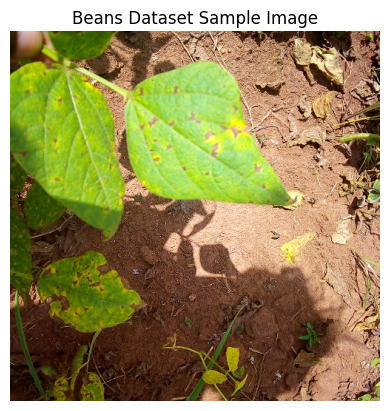

RuntimeError: Dataset scripts are no longer supported, but found common_voice.py

In [4]:
# Load image data (beans dataset)
beans = load_dataset('beans', split='train')
img_sample = beans[0]['image']
plt.imshow(img_sample)
plt.title('Beans Dataset Sample Image')
plt.axis('off')
plt.show()

# Load audio data (common_voice dataset)
cv = load_dataset('common_voice', 'en', split='train')
audio_sample = cv[0]['audio']['array']
sr = cv[0]['audio']['sampling_rate']
plt.figure(figsize=(10, 2))
plt.plot(audio_sample)
plt.title('Common Voice Sample Audio Waveform')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

# Load video data (kinetics dataset, if available)
try:
    kinetics = load_dataset('kinetics', split='train')
    video_sample = kinetics[0]['video']
    # Show first frame if video is available
    if isinstance(video_sample, list) and len(video_sample) > 0:
        frame = video_sample[0]
        plt.imshow(frame)
        plt.title('Kinetics Sample Video Frame')
        plt.axis('off')
        plt.show()
except Exception as e:
    print('Kinetics video dataset not available or not supported in this environment.')

## 3. Classical Deep Learning: Single Modality Example
Let's start with a simple image classification model using a CNN on the 'beans' dataset. This is a classical single-modality approach.

In [ ]:
# Simple CNN for image classification (beans dataset)
import torch.nn as nn
import torch.nn.functional as F
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1 = nn.Linear(16*32*32, 32)
        self.fc2 = nn.Linear(32, 3)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Preprocess image sample for model
transform = T.Compose([T.Resize((32,32)), T.ToTensor()])
img_tensor = transform(img_sample).unsqueeze(0)
model = SimpleCNN()
output = model(img_tensor)
pred = torch.argmax(output, dim=1).item()
print(f'Predicted class: {pred} (class names: {beans.info["features"]["label"]["names"]})')

## 4. Multimodal Deep Learning: Combining Image and Text
Now let's combine image and text modalities. We'll use a small sample from an image-text dataset (e.g., 'flickr8k'). We'll extract image features using a CNN and text features using a transformer or embedding, then combine them.

In [ ]:
# Load image-text data (flickr8k dataset)
flickr = load_dataset('flickr8k', split='train')
img = flickr[0]['image']
caption = flickr[0]['caption']
plt.imshow(img)
plt.title('Flickr8k Sample Image')
plt.axis('off')
plt.show()
print('Caption:', caption)

# Extract image features (using torchvision pretrained model)
import torchvision.models as models
resnet = models.resnet18(pretrained=True)
resnet.eval()
img_t = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])(img).unsqueeze(0)
with torch.no_grad():
    img_feat = resnet(img_t).numpy()[0]

# Extract text features (using transformers)
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')
inputs = tokenizer(caption, return_tensors='pt')
with torch.no_grad():
    text_feat = model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]

# Combine features (concatenate)
combined_feat = np.concatenate([img_feat, text_feat])
print('Combined feature shape:', combined_feat.shape)

## 5. Multimodal Deep Learning: Combining Audio and Text
Let's combine audio and text modalities using the 'common_voice' dataset. We'll extract audio features (MFCCs) and text features (embedding), then combine them.

In [ ]:
# Load audio-text sample (common_voice dataset)
audio_sample = cv[0]['audio']['array']
sr = cv[0]['audio']['sampling_rate']
text = cv[0]['sentence']
print('Audio text:', text)

# Extract audio features (MFCCs)
mfcc = librosa.feature.mfcc(y=audio_sample, sr=sr, n_mfcc=13)
audio_feat = mfcc.mean(axis=1)
plt.figure(figsize=(8,2))
plt.imshow(mfcc, aspect='auto', origin='lower')
plt.title('MFCCs of Sample Audio')
plt.xlabel('Frame')
plt.ylabel('MFCC Coefficient')
plt.colorbar()
plt.show()

# Extract text features (embedding)
inputs = tokenizer(text, return_tensors='pt')
with torch.no_grad():
    text_feat = model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]

# Combine features (concatenate)
combined_feat = np.concatenate([audio_feat, text_feat])
print('Combined audio-text feature shape:', combined_feat.shape)

## 6. Multimodal Deep Learning: Combining Video and Text
Now let's combine video and text modalities using the 'kinetics' dataset. We'll extract features from video frames and text labels, then combine them.

In [ ]:
# Load video-text sample (kinetics dataset, if available)
try:
    kinetics = load_dataset('kinetics', split='train')
    video_sample = kinetics[0]['video']
    label = kinetics[0]['label']
    # Extract features from first frame
    if isinstance(video_sample, list) and len(video_sample) > 0:
        frame = video_sample[0]
        frame_t = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])(frame).unsqueeze(0)
        with torch.no_grad():
            frame_feat = resnet(frame_t).numpy()[0]
        # Text label embedding
        inputs = tokenizer(label, return_tensors='pt')
        with torch.no_grad():
            text_feat = model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]
        combined_feat = np.concatenate([frame_feat, text_feat])
        print('Combined video-text feature shape:', combined_feat.shape)
        plt.imshow(frame)
        plt.title(f'Kinetics Sample Frame - Label: {label}')
        plt.axis('off')
        plt.show()
except Exception as e:
    print('Kinetics video dataset not available or not supported in this environment.')

## 7. Simple Multimodal Model Architecture
Let's build a basic multimodal model that fuses features from two modalities (e.g., image and text). We'll concatenate features and pass them through dense layers for classification or regression.

In [ ]:
# Example multimodal model (image-text fusion)
class MultimodalNet(nn.Module):
    def __init__(self, img_dim, text_dim, hidden_dim=64, out_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(img_dim + text_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
    def forward(self, img_feat, text_feat):
        x = torch.cat([img_feat, text_feat], dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Example usage with extracted features
img_feat_torch = torch.tensor(img_feat).unsqueeze(0)
text_feat_torch = torch.tensor(text_feat).unsqueeze(0)
model = MultimodalNet(img_feat_torch.shape[1], text_feat_torch.shape[1])
output = model(img_feat_torch, text_feat_torch)
print('Multimodal model output:', output)

## 8. Training and Evaluation of Multimodal Models
We'll train the multimodal model on a small batch and evaluate its performance. For demonstration, we'll use synthetic labels and compare with classical single-modality models.

In [ ]:
# Synthetic training example for multimodal model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
labels = torch.tensor([random.randint(0,2)])
for epoch in range(5):
    optimizer.zero_grad()
    output = model(img_feat_torch, text_feat_torch)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')
print('Training complete. (Demo only)')

## 9. Visualizing Multimodal Inputs and Outputs
Let's visualize some multimodal inputs and model outputs. We'll display images, audio waveforms, video frames, text, and model predictions/embeddings.

In [ ]:
# Visualize multimodal inputs and outputs
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(img_sample)
axs[0].set_title('Image Input')
axs[0].axis('off')
axs[1].plot(audio_sample)
axs[1].set_title('Audio Input')
axs[1].set_xlabel('Sample Index')
axs[1].set_ylabel('Amplitude')
axs[2].bar(range(len(output[0].detach().numpy())), output[0].detach().numpy())
axs[2].set_title('Model Output (Class Scores)')
plt.tight_layout()
plt.show()
print('Text Input:', caption)
print('Model Embedding (first 5 values):', output[0].detach().numpy()[:5])